In [ ]:
# Autoreload
%load_ext autoreload
%autoreload 2

import pygad
from scripts import Optimizer,Character,Chromosome,get_item_set
import json
with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [ ]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 500,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980 # Vulbis
                              ]  # Excluded items
                },
                "preferences": {
                    "lower": {
                        12: 12,  # AP
                        8: 6,   # MP
                        29: 75,   # Crit
                    },
                    "upper": {} 
                },
                "level_offset": 10,  # Level offset for items
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    8:1
                    },  # Exo MP
                "elements" : [
                    36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ]
            },
        }
config["language"] = config["optimizer"]["language"]

In [ ]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["language"]],
        "set" : item_set["name"][config["language"]] if item_set else None,
    }
Items = pd.DataFrame.from_dict(dct, orient='index')

In [ ]:
char = Character(**config["character"])
opt = Optimizer(char, items, item_sets, **config["optimizer"])

Total pools: 16 with sizes [69, 118, 71, 71, 62, 81, 40, 88, 69, 145, 326, 326, 326, 326, 326, 326]
Total combinations: 10^33.94


In [ ]:
opt.optimize()

In [ ]:
(opt.solution.fitness, opt.solution.get_damage())

(2070.75, 2070.75)

In [ ]:
opt.solution.totals_summary(effect_descriptions,
                      language=config["language"])#.sort_values("value",ascending=False)

,description,value
0,Intercambiable:,0.0
8,PM,6.0
9,vitalidad,2915.0
10,sabiduría,380.0
12,PA,12.0
13,inteligencia,200.0
16,% resistencia al aire,23.0
17,% resistencia al agua,30.0
22,suerte,200.0
24,iniciativa,1200.0


In [ ]:
set_summary = opt.solution.set_summary(language=config["language"])
set_summary

,type_id,type,description,level,set
694,13,Dofus,Crimson Dofus,110,None
739,13,Dofus,Turquoise Dofus,160,None
7043,13,Dofus,Ice Dofus,180,None
8993,2,Sword,Blord Warrior's Cursed Sword,200,None
13344,13,Dofus,Dolmanax,100,None
14094,1,Amulet,Treadfast Amulet,200,Treadfast Set
14095,4,Belt,Treadfast Belt,200,Treadfast Set
14096,5,Boots,Treadfast Boots,200,Treadfast Set
16332,13,Trophy,Major Vigour,150,None
16335,13,Trophy,Nomad,100,None


In [ ]:
set_summary["set"].value_counts()

set
Set de estrígido     3
Set de Cocuzko       2
Set de Torkelonia    2
Set de Corrupción    1
Name: count, dtype: int64

Text(0, 0.5, 'Best Fitness')

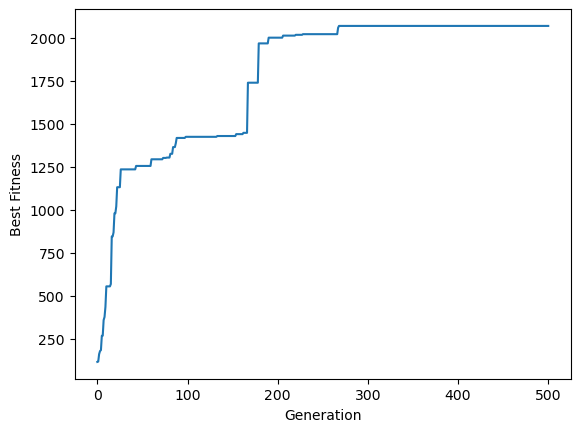

In [ ]:
import matplotlib.pyplot as plt
plt.plot(opt.ga_instance.best_solutions_fitness)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

In [ ]:
assert False

AssertionError: 

In [ ]:
chr = Chromosome(char,
                 items,
                 item_sets,
                 [
                    8993, # Espada
                    13641, 13643, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    19985, # Vuelo
                    18670, # Escudo
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 config["optimizer"]["preferences"])
chr.fitness

1890.67

In [ ]:
chr.set_summary(language=config["language"])

,type_id,type,description,level,set
694,13,Dofus,Dofus Púrpura,110,None
737,13,Dofus,Dofus Esmeralda,100,None
739,13,Dofus,Dofus Turquesa,160,None
7043,13,Dofus,Dofus de los hielos,180,None
7754,13,Dofus,Dofus Ocre,160,None
8993,2,Espada,Espada maldita del gran Desangrador Guerrero,200,None
13641,10,Sombrero,Gorro de Noai Aludem,198,Set de Noai Aludem
13642,3,Anillo,Anillo de Noai Aludem,197,Set de Noai Aludem
13643,5,Bota,Getas de Noai Aludem,196,Set de Noai Aludem
13673,12,Mascota,Lokulto,20,None


In [ ]:
chr.totals_summary(effect_descriptions,
                      language=config["language"])

,description,value
0,Intercambiable:,0.0
8,PM,6.0
9,vitalidad,2365.0
10,sabiduría,390.0
12,PA,12.0
13,inteligencia,550.0
14,de resistencia al fuego,35.0
15,de resistencia a la tierra,10.0
16,% resistencia al aire,34.0
17,% resistencia al agua,46.0


In [ ]:
elements = set()
for i in items.values():
    conditions = i["conditions"]
    if not conditions:
        continue
    dct = conditions["value"]
    if not dct:
        continue
    elements.add(dct["element"])

elements

{'CA',
 'CC',
 'CI',
 'CM',
 'CP',
 'CS',
 'CV',
 'CW',
 'PK',
 'PL',
 'PO',
 'PZ',
 'Pa',
 'Pk',
 'Po',
 'Pz',
 'ca',
 'cc',
 'ci',
 'cs',
 'cv',
 'cw'}

In [ ]:
conditions = set()
for i in opt.items.values():
    if not i.get("conditions"):
        continue
    for c in i["conditions"]:
        conditions.add(c["element"])

TypeError: string indices must be integers

In [ ]:
i["conditions"]

{'value': {'element': 'PZ',
  'element_id': 252,
  'operator': '=',
  'value': 1,
  'templated': {'de': 'Abonniert',
   'en': 'Be subscribed',
   'es': 'Estar abonado',
   'fr': 'Être abonné',
   'pt': 'Ser assinante'}},
 'is_operand': True,
 'relation': None,
 'children': None}

In [ ]:
opt.get_damage(opt.get_chromosome_weapon(solution), solution)

0.0


1476.225